# Proyecto Final - Modelamiento Computacional de Procesos Geoquímicos

**Autora:** Maria Valentina Becerra  
**Tema:** Replicación de las funcionalidades de GCDkit (R) en Python y análisis comparativo (Estadística Descriptiva + PCA) de los complejos Paipa-Iza y Vetas-California.

> En este notebook voy a construir un flujo de trabajo en Python que me permita:
> 1. Cargar y limpiar mi base de datos geoquímica.
> 2. Generar los diagramas clásicos de clasificación e interpretación petrogenética (TAS, AFM, Harker, discriminación tectónica, Spider y REE normalizados al Condrito de Boynton, 1984).
> 3. Aplicar estadística descriptiva y un Análisis de Componentes Principales (PCA) para comparar de forma cuantitativa los dos complejos.


---
## 1. Importación de librerías

Aquí cargo todas las herramientas que necesito a lo largo del notebook. Lo hago al inicio para que cualquiera que abra mi código vea de entrada de qué depende el flujo de trabajo.

In [25]:
#  Manejo de datos 
import pandas as pd          # Tablas (mi dataframe principal)
import numpy as np           # Operaciones numéricas y matrices

# Visualización 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

#  Estadística (scipy y sklearn) 
from scipy import stats                           # Pruebas t de Student, normalidad, etc.
from sklearn.preprocessing import StandardScaler  # Estandarización antes del PCA
from sklearn.decomposition import PCA             # Análisis de Componentes Principales
from sklearn.impute import SimpleImputer          # Relleno de datos faltantes

#  Ajustes visuales generales 
plt.rcParams.update({
    'figure.dpi'  : 110,
    'font.size'   : 10,
    'axes.grid'   : True,
    'grid.alpha'  : 0.3,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

import warnings
warnings.filterwarnings('ignore')

print(' Librerías cargadas correctamente.')

 Librerías cargadas correctamente.


---
## 2. Carga y depuración de la base de datos *(Fase 1 de la metodología)*

Leo mi archivo de Excel y aplico una limpieza en tres pasos:

1. **Fuerzo la conversión numérica** de todas las columnas geoquímicas (algunos campos del Excel pueden tener texto como "<0.1" o "bdl" que hay que convertir a NaN para no romper las operaciones matemáticas).
2. **Unifico etiquetas de región**: Iza-Paipa e Iza dome - Paipa-Iza; California-Betas - Vetas-California.
3. **Filtro** los dos complejos a comparar (Quetame queda omitido porque aún no tengo los datos del laboratorio).

In [26]:
# Ruta al archivo de Excel con mi compilación bibliográfica
RUTA_DATOS = r'C:/Users/valen/OneDrive/Desktop/8vo SEM/Modelamiento geoquímico/proyecto_final/datos.xlsx'

# Lectura 
df_raw = pd.read_excel(RUTA_DATOS)
print(f'Dimensiones originales: {df_raw.shape[0]} muestras × {df_raw.shape[1]} columnas')
df_raw.head()

Dimensiones originales: 23 muestras × 67 columnas


,Sample,Compare,Work,Symbol,Color,Region,lithology,Edad (Ma),Método dat,SiO2,...,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu
0,119i,3,"Pardo et al, 2005",Solid triangle,Green,Iza-Paipa,Kfeldspar trachyte,"Pleistoceno 1,9-2,5",K-Ar y Ar-Ar,70.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,069i,4,"Pardo et al, 2005",Solid triangle,Green,Iza-Paipa,Kfeldspar trachyte,"Pleistoceno 1,9-2,5",K-Ar y Ar-Ar,68.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,084i,5,"Pardo et al, 2005",Solid triangle,Green,Iza-Paipa,Kfeldspar trachyte,"Pleistoceno 1,9-2,5",K-Ar y Ar-Ar,72.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,005E,6,"Pardo et al, 2005",Solid triangle,Green,Iza-Paipa,Kfeldspar trachyte,"Pleistoceno 1,9-2,5",K-Ar y Ar-Ar,72.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,102i,7,"Pardo et al, 2005",Solid triangle,Green,Iza-Paipa,Trachyte,"Pleistoceno 1,9-2,5",K-Ar y Ar-Ar,71.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
#  Defino listas de columnas por grupo 
# Las defino aquí (antes de cualquier limpieza) para poder aplicar la conversión
# numérica y usarlas en todos los bloques siguientes.
MAYORES = ['SiO2','TiO2','Al2O3','Fe2O3tot','MnO','MgO','CaO','Na2O','K2O','P2O5']
TRAZAS  = ['Rb','Ba','Sr','Y','Nb','Ta','Zr','Hf','Th','U','Pb','V','Cr','Ni','Co','Sc']
REE     = ['La','Ce','Pr','Nd','Sm','Eu','Gd','Tb','Dy','Ho','Er','Tm','Yb','Lu']

#  Conversión numérica forzada 
# Algunos valores en el Excel vienen como texto ("<0.1", "bdl", etc.).
# Con errors='coerce' los convierto a NaN para que no rompan las operaciones matemáticas.
cols_geo = MAYORES + TRAZAS + REE
for col in cols_geo:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

#  Unificación de etiquetas de región 
mapa_complejos = {
    'Iza-Paipa'        : 'Paipa-Iza',
    'Iza dome'         : 'Paipa-Iza',
    'California-Betas' : 'Vetas-California',
}
df_raw['Complejo'] = df_raw['Region'].astype(str).str.strip().map(
    {k.strip(): v for k, v in mapa_complejos.items()}
)

#  Filtro: solo los dos complejos del análisis 
df = df_raw[df_raw['Complejo'].isin(['Paipa-Iza', 'Vetas-California'])].copy()
df = df.reset_index(drop=True)

#  Colores y marcadores fijos para mantener consistencia visual 
COLORES   = {'Paipa-Iza': '#1f77b4', 'Vetas-California': '#d62728'}
MARCADORES= {'Paipa-Iza': 'o',       'Vetas-California': 's'}

print('Muestras por complejo:')
print(df['Complejo'].value_counts().to_string())

Muestras por complejo:
Complejo
Paipa-Iza           18
Vetas-California     5


In [28]:
# Diagnóstico de datos faltantes 
# Reviso cuántos NaN tengo en cada grupo de elementos.
# Esto me ayuda a decidir cómo manejar los faltantes en el PCA.
print('Faltantes en elementos MAYORES:')
print(df[MAYORES].isna().sum().to_string())
print('\nFaltantes en TRAZAS (columnas disponibles):')
cols_trazas_ok = [c for c in TRAZAS if c in df.columns]
print(df[cols_trazas_ok].isna().sum().to_string())
print('\nFaltantes en REE:')
print(df[REE].isna().sum().to_string())

Faltantes en elementos MAYORES:
SiO2         0
TiO2         0
Al2O3        0
Fe2O3tot     0
MnO         13
MgO          0
CaO          1
Na2O         0
K2O          0
P2O5         0

Faltantes en TRAZAS (columnas disponibles):
Rb     5
Ba     5
Sr     5
Y      5
Nb     5
Ta     5
Zr     5
Hf     5
Th     5
U      5
Pb     9
V      5
Cr    19
Ni     5
Co     8
Sc     9

Faltantes en REE:
La    5
Ce    5
Pr    5
Nd    5
Sm    5
Eu    5
Gd    5
Tb    5
Dy    5
Ho    5
Er    5
Tm    5
Yb    5
Lu    5


---
## 3. Recálculo de elementos mayores a base anhidra (100 % libre de volátiles)

Antes de hacer cualquier diagrama de clasificación recalculo los óxidos a base anhidra: descuento el LOI (pérdida por ignición) y reescalo para que la suma sea exactamente 100 %. Esto es lo que GCDkit hace internamente antes de graficar. Sin este paso, comparar muestras con distintos contenidos de agua/CO₂ daría resultados sesgados.

In [29]:
def recalcular_anhidro(dframe, mayores=MAYORES):
    """
    Recibo el dataframe y devuelvo las columnas de óxidos mayores recalculadas
    al 100 % en base anhidra, añadiéndolas con sufijo '_anh'.
    Primero fuerzo la conversión numérica para evitar errores con valores de texto.
    """
    # Extraigo solo los óxidos disponibles y los convierto a float
    cols_ok  = [c for c in mayores if c in dframe.columns]
    bloque   = dframe[cols_ok].apply(pd.to_numeric, errors='coerce').copy()

    # Sumo fila a fila (ignoro NaN para no perder muestras con un óxido faltante)
    suma     = bloque.sum(axis=1, skipna=True)

    # Divido cada óxido entre la suma de esa muestra y multiplico por 100
    anh      = bloque.div(suma, axis=0) * 100
    anh.columns = [c + '_anh' for c in cols_ok]

    return pd.concat([dframe, anh], axis=1)

df = recalcular_anhidro(df)

# Verificación: todas las filas deben sumar ~100
cols_anh = [c + '_anh' for c in MAYORES if c + '_anh' in df.columns]
sumas = df[cols_anh].sum(axis=1).round(2)
print('Suma por muestra en base anhidra (debe ser ~100 en todas):')
print(sumas.to_string())

Suma por muestra en base anhidra (debe ser ~100 en todas):
0     100.0
1     100.0
2     100.0
3     100.0
4     100.0
5     100.0
6     100.0
7     100.0
8     100.0
9     100.0
10    100.0
11    100.0
12    100.0
13    100.0
14    100.0
15    100.0
16    100.0
17    100.0
18    100.0
19    100.0
20    100.0
21    100.0
22    100.0


---
## 4. Estadística descriptiva *(Fase 2 – análisis estadístico)*

Calculo medidas resumen (media, mediana, desviación estándar, mínimo y máximo) por complejo. Esto me da una primera idea cuantitativa de qué tan parecidos o distintos son los dos cuerpos. Luego aplico una prueba t de Welch (con scipy.stats) para saber si la diferencia de medias es estadísticamente significativa.

In [30]:
# Resumen estadístico por complejo para los óxidos mayores en base anhidra
vars_desc = [c + '_anh' for c in MAYORES]
resumen   = df.groupby('Complejo')[vars_desc].agg(['mean','median','std','min','max']).round(2)
resumen

SiO2_anh                            TiO2_anh               \
                     mean median   std    min    max     mean median   std   
Complejo                                                                     
Paipa-Iza           70.69  70.88  2.56  66.22  76.34     0.28   0.25  0.14   
Vetas-California    66.88  66.88  0.00  66.88  66.88     0.35   0.35  0.00   

                              ... K2O_anh                          P2O5_anh  \
                   min   max  ...    mean median  std   min    max     mean   
Complejo                      ...                                             
Paipa-Iza         0.13  0.79  ...    5.77   4.61  2.9  1.67  11.68     0.08   
Vetas-California  0.35  0.35  ...    3.80   3.80  0.0  3.80   3.80     0.17   

                                           
                 median   std   min   max  
Complejo                                   
Paipa-Iza          0.06  0.07  0.00  0.22  
Vetas-California   0.17  0.00  0.17  0.17  

[2 rows x 50 columns]

In [31]:
# Prueba t de Welch óxido por óxido 
# Uso la versión de Welch (equal_var=False) porque no asumo que las varianzas
# de los dos grupos sean iguales (son muestras de tamaños distintos).
# Si p < 0.05 concluyo que ese óxido es significativamente diferente entre complejos.
filas = []
for var in vars_desc:
    a = df.loc[df['Complejo'] == 'Paipa-Iza',        var].dropna()
    b = df.loc[df['Complejo'] == 'Vetas-California', var].dropna()
    if len(a) > 1 and len(b) > 1:
        t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
        filas.append({
            'Óxido'          : var.replace('_anh',''),
            'Media Paipa-Iza': round(a.mean(), 2),
            'Media Vetas-Cal': round(b.mean(), 2),
            't-estadístico'  : round(t_stat, 2),
            'p-valor'        : round(p_val, 4),
            '¿Diferentes (p<0.05)?': 'Sí ' if p_val < 0.05 else 'No'
        })

tabla_t = pd.DataFrame(filas)
tabla_t

,Óxido,Media Paipa-Iza,Media Vetas-Cal,t-estadístico,p-valor,¿Diferentes (p<0.05)?
0,SiO2,70.69,66.88,6.31,0.0000,Sí
1,TiO2,0.28,0.35,-2.11,0.0499,Sí
2,Al2O3,19.01,17.95,1.38,0.1845,No
3,Fe2O3tot,1.79,2.56,-3.53,0.0026,Sí
4,MnO,0.03,0.04,-0.46,0.6669,No
5,MgO,0.14,0.67,-10.47,0.0000,Sí
6,CaO,0.22,3.54,-48.60,0.0000,Sí
7,Na2O,2.02,4.03,-3.23,0.0049,Sí
8,K2O,5.77,3.80,2.88,0.0103,Sí
9,P2O5,0.08,0.17,-6.16,0.0000,Sí


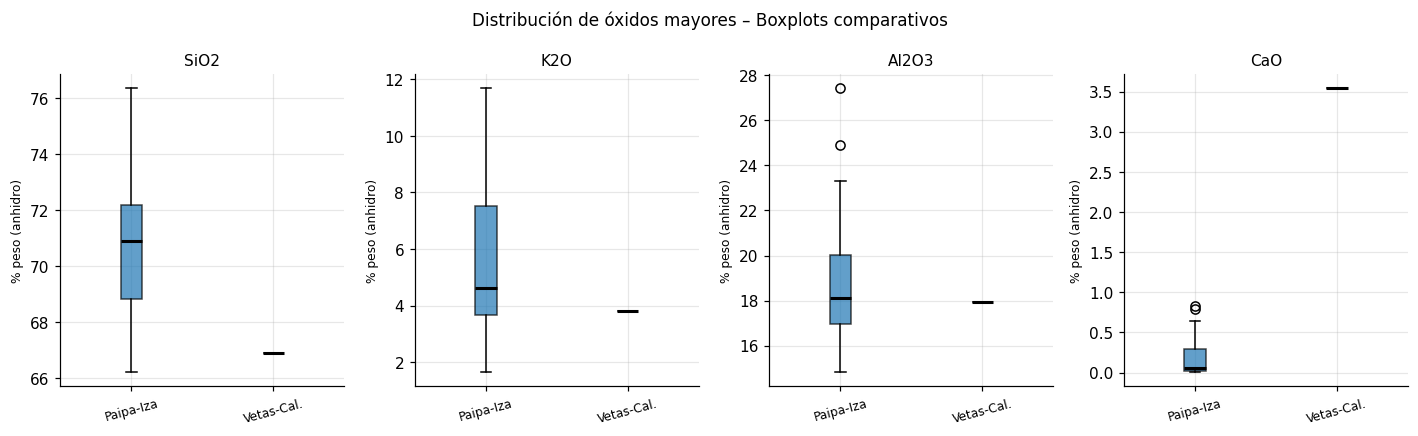

In [32]:
# Boxplots comparativos para los 4 óxidos más relevantes 
# Visualizo la dispersión de SiO2, K2O, Al2O3 y CaO en un solo panel.
oxidos_box = ['SiO2_anh', 'K2O_anh', 'Al2O3_anh', 'CaO_anh']
fig, axes  = plt.subplots(1, 4, figsize=(13, 4))

for ax, ox in zip(axes, oxidos_box):
    datos_box  = [df.loc[df['Complejo'] == c, ox].dropna().values
                  for c in ['Paipa-Iza', 'Vetas-California']]
    bp = ax.boxplot(datos_box, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORES.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Paipa-Iza', 'Vetas-Cal.'], rotation=15, fontsize=8)
    ax.set_title(ox.replace('_anh', ''), fontsize=10)
    ax.set_ylabel('% peso (anhidro)', fontsize=8)

fig.suptitle('Distribución de óxidos mayores – Boxplots comparativos', fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. Diagrama TAS *(Total Alkali vs Silica – Le Bas et al., 1986)*

El diagrama TAS clasifica rocas volcánicas según el contenido de SiO₂ vs Na₂O+K₂O. Dibujo las fronteras del diagrama original Le Bas (1986) como polígonos y luego sobrepongo mis muestras. La línea punteada separa la serie alcalina (arriba) de la subalcalina (abajo) según Irvine & Baragar (1971).

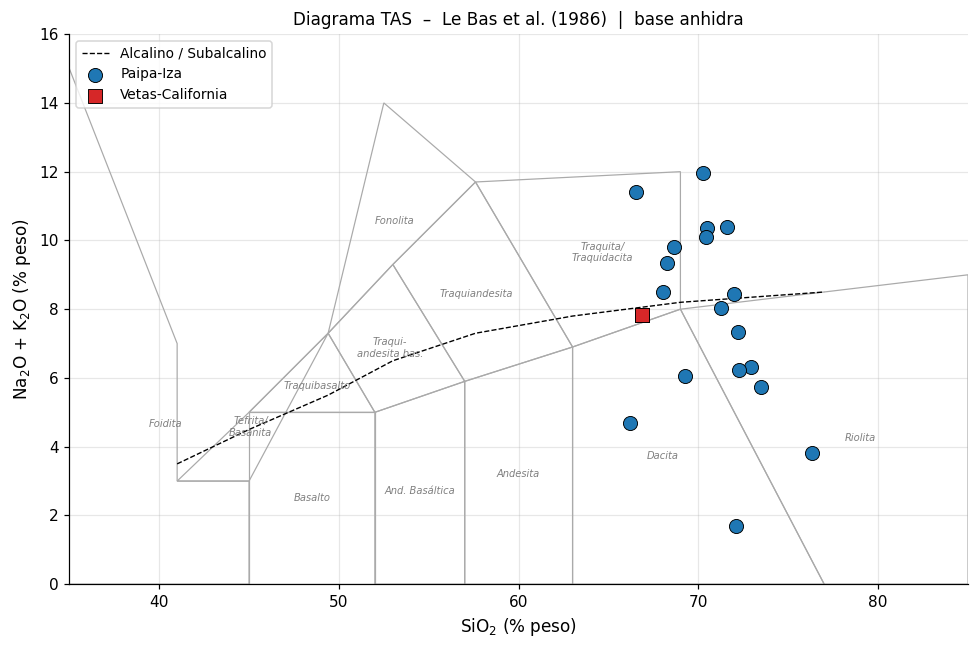

In [48]:
def dibujar_TAS(dframe):
    """Genera el diagrama TAS con los campos de Le Bas et al. (1986)."""
    fig, ax = plt.subplots(figsize=(9, 6))

    # Polígonos de campos (coordenadas Le Bas 1986, corregidas)
    # La frontera Dacita/Riolita se ubica en SiO2 ~ 69 % (no en 77 %).
    campos = {
        'Basalto'               : [(45,0),(45,5),(52,5),(52,0)],
        'And. Basáltica'        : [(52,0),(52,5),(57,5.9),(57,0)],
        'Andesita'              : [(57,0),(57,5.9),(63,6.9),(63,0)],
        'Dacita'                : [(63,0),(77,0),(69,8),(63,6.9)],
        'Riolita'               : [(69,8),(77,0),(85,0),(85,9)],
        'Traquibasalto'         : [(45,5),(49.4,7.3),(52,5)],
        'Traqui-\nandesita bas.': [(49.4,7.3),(53,9.3),(57,5.9),(52,5)],
        'Traquiandesita'        : [(53,9.3),(57.6,11.7),(63,6.9),(57,5.9)],
        'Traquita/\nTraquidacita':[(57.6,11.7),(69,12),(69,8),(63,6.9)],
        'Fonolita'              : [(52.5,14),(57.6,11.7),(53,9.3),(49.4,7.3)],
        'Tefrita/\nBasanita'    : [(41,3),(45,5),(49.4,7.3),(45,3)],
        'Foidita'               : [(35,0),(35,15),(41,7),(41,3),(45,3),(45,0)]
    }
    for nombre, vert in campos.items():
        poly = plt.Polygon(vert, fill=False, edgecolor='#aaaaaa', linewidth=0.8)
        ax.add_patch(poly)
        cx = np.mean([v[0] for v in vert])
        cy = np.mean([v[1] for v in vert])
        ax.text(cx, cy, nombre, fontsize=6.5, ha='center', va='center',
                color='gray', style='italic', linespacing=1.2)

    # Línea alcalina/subalcalina (Irvine & Baragar 1971) 
    x_div = [41, 45, 49.4, 53, 57.6, 63, 69, 77]
    y_div = [3.5, 4.5, 5.5, 6.5, 7.3, 7.8, 8.2, 8.5]
    ax.plot(x_div, y_div, 'k--', linewidth=0.9, label='Alcalino / Subalcalino')

    # Mis muestras
    for complejo, sub in dframe.groupby('Complejo'):
        x = sub['SiO2_anh']
        y = sub['Na2O_anh'] + sub['K2O_anh']
        ax.scatter(x, y, s=85, c=COLORES[complejo], marker=MARCADORES[complejo],
                   edgecolor='k', linewidth=0.6, label=complejo, zorder=5)

    ax.set_xlim(35, 85)
    ax.set_ylim(0, 16)
    ax.set_xlabel('SiO$_2$ (% peso)', fontsize=11)
    ax.set_ylabel('Na$_2$O + K$_2$O (% peso)', fontsize=11)
    ax.set_title('Diagrama TAS  –  Le Bas et al. (1986)  |  base anhidra', fontsize=11)
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

dibujar_TAS(df)

### Interpretación del TAS

- Las muestras del complejo **Paipa-Iza** se ubican mayoritariamente en los campos de **Traquidacita, Traquita y Riolita**, casi todas por encima de la línea de Irvine & Baragar (1971), confirmando su carácter alcalino a transicional. Esto es coherente con lo reportado por Cepeda & Pardo (2004) y Pardo et al. (2005), quienes describen el vulcanismo de Paipa-Iza como una serie félsica alcalina a peralcalina de edad Plio-Pleistocena emplazada sobre la Cordillera Oriental.
- Las muestras de **Vetas-California** se concentran en el campo de **Dacita-Riolita**, por debajo de la línea alcalina/subalcalina, indicando una afinidad subalcalina clara. Esto coincide con la caracterización de Mantilla et al. (2009, 2013) y Bissig et al. (2014), que clasifican estos pórfidos del Mioceno tardío como calco-alcalinos de alto K asociados a la subducción Andina y al sistema epitermal-porfídico de Au.

**Significado petrogenético:** la diferencia en alcalinidad entre los dos cuerpos sugiere fuentes y/o procesos petrogenéticos distintos: Paipa-Iza refleja un magmatismo más enriquecido (probablemente con mayor contribución cortical o un manto metasomatizado), mientras que Vetas-California muestra la huella típica de un arco continental.

---
## 6. Diagrama AFM *(Irvine & Baragar, 1971)*

Este diagrama ternario diferencia series tholeíticas de calcoalcalinas Los vértices son **A** = Na₂O+K₂O, **F** = FeO total y **M** = MgO. Como mi tabla tiene Fe₂O₃ total, aplico la conversión estándar multiplicando por 0.8998.

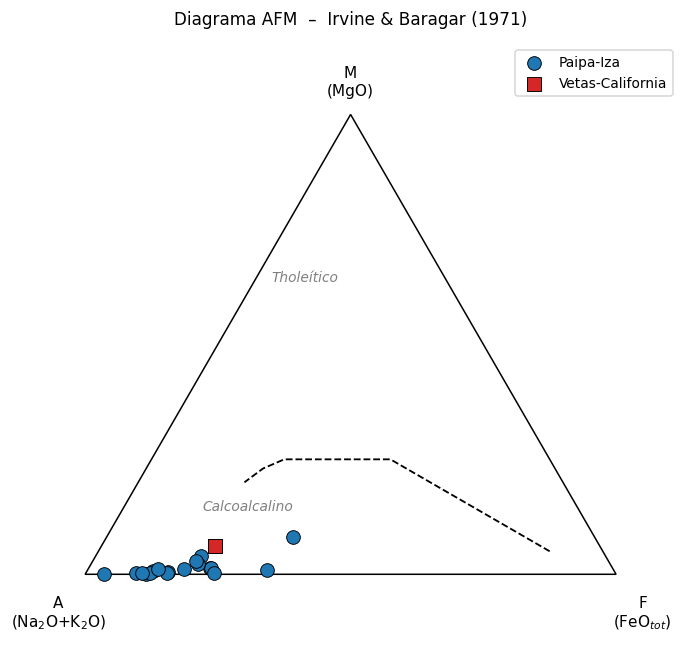

In [35]:
def tern_a_xy(A, F, M):
    """Convierte proporciones ternarias (A, F, M) a coordenadas cartesianas (x, y)."""
    total = A + F + M
    A, F, M = A / total, F / total, M / total
    # En un triángulo equilátero: vértice izquierdo=A, derecho=F, superior=M
    x = 0.5 * (2 * F + M)
    y = (np.sqrt(3) / 2) * M
    return x, y

def dibujar_AFM(dframe):
    """Genera el diagrama ternario AFM con la curva de Irvine & Baragar (1971)."""
    fig, ax = plt.subplots(figsize=(7, 6))

    # Triángulo base 
    tri = plt.Polygon([(0,0),(1,0),(0.5, np.sqrt(3)/2)],
                      fill=False, edgecolor='k', linewidth=1)
    ax.add_patch(tri)
    ax.text(-0.05, -0.04, 'A\n(Na$_2$O+K$_2$O)', fontsize=10, ha='center', va='top')
    ax.text(1.05,  -0.04, 'F\n(FeO$_{tot}$)',     fontsize=10, ha='center', va='top')
    ax.text(0.5,  np.sqrt(3)/2+0.03, 'M\n(MgO)',  fontsize=10, ha='center', va='bottom')

    # Curva Irvine & Baragar 1971 (puntos publicados) 
    curva = np.array([
        [0.10,0.85,0.05],[0.15,0.75,0.10],[0.20,0.65,0.15],
        [0.25,0.55,0.20],[0.30,0.45,0.25],[0.38,0.37,0.25],
        [0.45,0.30,0.25],[0.50,0.25,0.25],[0.55,0.22,0.23],
        [0.60,0.20,0.20]
    ])
    xc, yc = tern_a_xy(curva[:,0], curva[:,1], curva[:,2])
    ax.plot(xc, yc, 'k--', linewidth=1.2)
    ax.text(0.35, 0.55, 'Tholeítico',   fontsize=9, color='gray', style='italic')
    ax.text(0.22, 0.12, 'Calcoalcalino',fontsize=9, color='gray', style='italic')

    # Mis muestras
    for complejo, sub in dframe.groupby('Complejo'):
        A = sub['Na2O_anh'] + sub['K2O_anh']
        F = sub['Fe2O3tot_anh'] * 0.8998   # Fe₂O₃total → FeO total
        M = sub['MgO_anh']
        # Descarto filas con cualquier NaN en A, F o M
        mask = ~(A.isna() | F.isna() | M.isna())
        x, y = tern_a_xy(A[mask].values, F[mask].values, M[mask].values)
        ax.scatter(x, y, s=80, c=COLORES[complejo], marker=MARCADORES[complejo],
                   edgecolor='k', linewidth=0.6, label=complejo, zorder=5)

    ax.set_xlim(-0.12, 1.12)
    ax.set_ylim(-0.12, 1.00)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Diagrama AFM  –  Irvine & Baragar (1971)', fontsize=11, pad=12)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

dibujar_AFM(df)

### Interpretación del AFM

- Ambos complejos se proyectan **cerca del vértice A** (Na₂O+K₂O), por debajo de la curva de Irvine & Baragar (1971), es decir, dentro del campo **calco-alcalino**. Esto es lógico porque ambas son rocas félsicas muy diferenciadas (alto SiO₂), donde MgO y FeO ya están empobrecidos por la cristalización fraccionada previa de fases ferromagnesianas (olivino, piroxeno, hornblenda, biotita).

- **Paipa-Iza** tiende a desplazarse aún más hacia el vértice A por su mayor contenido de álcalis, consistente con su carácter alcalino-traquítico identificado en el TAS.
- **Vetas-California** queda ligeramente más cerca del lado A–F del triángulo, propio de una serie calco-alcalina de alto K.

**Limitación:** el AFM fue diseñado para series máficas-intermedias. Para rocas tan félsicas como las nuestras pierde resolución y solo confirma que ninguno de los dos complejos sigue la tendencia tholeítica de enriquecimiento en Fe lo cual es esperable en ambientes de arco continental y plateau intracontinental.

---
## 7. Diagramas de Harker

Los diagramas de Harker grafican cada óxido frente al SiO₂ (índice de diferenciación más usado). Sirven para ver si los dos complejos siguen la misma tendencia de evolución magmática (cristalización fraccionada, mezcla de magmas, etc.). Automatizo la generación de todos los óxidos en un solo panel.

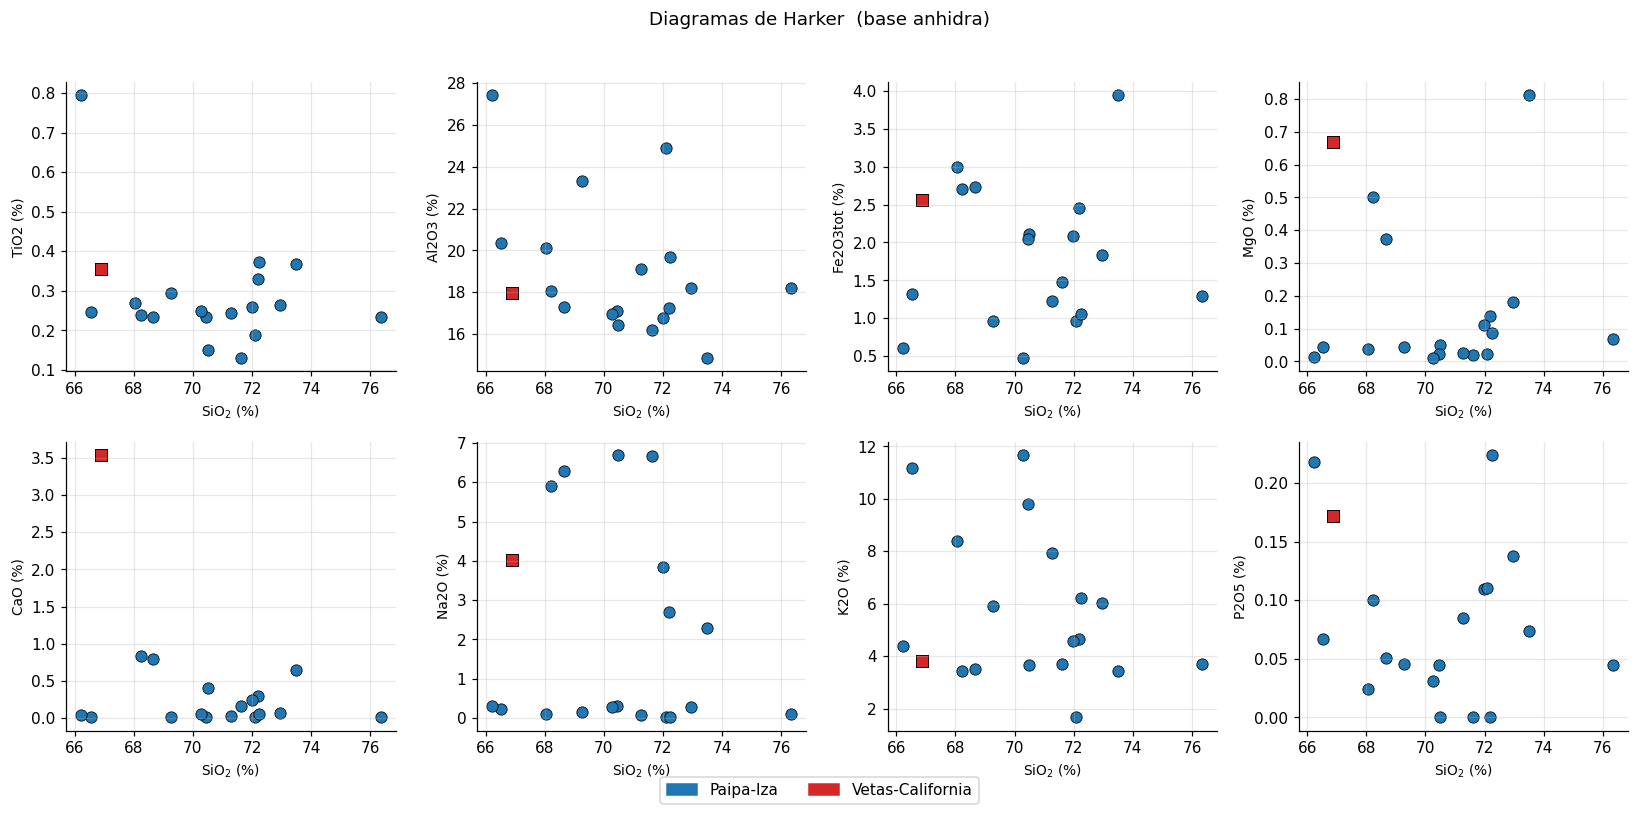

In [36]:
def diagramas_Harker(dframe):
    """Genera 8 diagramas SiO2 vs cada óxido mayor en un solo panel de 2×4."""
    oxidos_y = ['TiO2_anh','Al2O3_anh','Fe2O3tot_anh','MgO_anh',
                'CaO_anh','Na2O_anh','K2O_anh','P2O5_anh']
    fig, axes = plt.subplots(2, 4, figsize=(15, 7))
    leyenda_hecha = False

    for ax, ox in zip(axes.flat, oxidos_y):
        for complejo, sub in dframe.groupby('Complejo'):
            ax.scatter(
                sub['SiO2_anh'], sub[ox],
                s=55, c=COLORES[complejo], marker=MARCADORES[complejo],
                edgecolor='k', linewidth=0.5, label=complejo if not leyenda_hecha else '_'
            )
        ax.set_xlabel('SiO$_2$ (%)', fontsize=9)
        ax.set_ylabel(ox.replace('_anh','') + ' (%)', fontsize=9)
        leyenda_hecha = True

    # Una sola leyenda compartida para todo el panel
    handles = [mpatches.Patch(color=c, label=k) for k, c in COLORES.items()]
    fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle('Diagramas de Harker  (base anhidra)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

diagramas_Harker(df)

### Interpretación de los diagramas de Harker

**Tendencias que se observan al aumentar SiO₂:**

| Óxido | Tendencia esperada | ¿Se cumple en mis datos? | Fase mineral implicada |
|---|---|---|---|
| TiO₂ | ↓ | Sí, en ambos complejos | Fraccionación de óxidos Fe-Ti (ilmenita, magnetita) |
| Fe₂O₃ₜ | ↓ | Sí | Magnetita + máficos |
| MgO | ↓ | Sí (muy bajo en ambos) | Cristalización temprana de olivino/piroxeno |
| CaO | ↓ | Sí | Plagioclasa cálcica + clinopiroxeno |
| Al₂O₃ | ↓ moderada | Sí | Plagioclasa |
| Na₂O | ≈ o ligero ↑ | Plano/ligero ↑ | Plagioclasa sódica en residuo |
| K₂O | ↑ | Sí, marcado | Feldespato-K incompatible hasta etapa tardía |
| P₂O₅ | ↓ después de saturarse en apatito | Sí | Apatito |

las tendencias son las clásicas de una **cristalización fraccionada** que va de magmas intermedios a félsicos. Ambos complejos siguen trayectorias paralelas en la mayoría de óxidos, lo que indica procesos magmáticos similares (fraccionación), pero Paipa-Iza muestra K₂O sistemáticamente más alto para un mismo SiO₂, esto refuerza su afinidad alcalina/shoshonítica frente al carácter calco-alcalino de Vetas-California, como ya se documenta en la literatura regional (Pardo et al., 2005; Mantilla et al., 2013).

---
## 8. Diagramas de discriminación tectónica *(Pearce et al., 1984)*

Para granitoides y rocas félsicas, Pearce et al. (1984) propusieron diagramas con elementos traza *inmóviles* (Rb, Y, Nb) que no se alteran por procesos hidrotermales y permiten distinguir ambientes tectónicos:
- **VAG** = Volcanic Arc Granites (arco volcánico)
- **syn-COLG** = Sin-collision Granites (colisión)
- **WPG** = Within-Plate Granites (intraplaca)
- **ORG** = Ocean-Ridge Granites

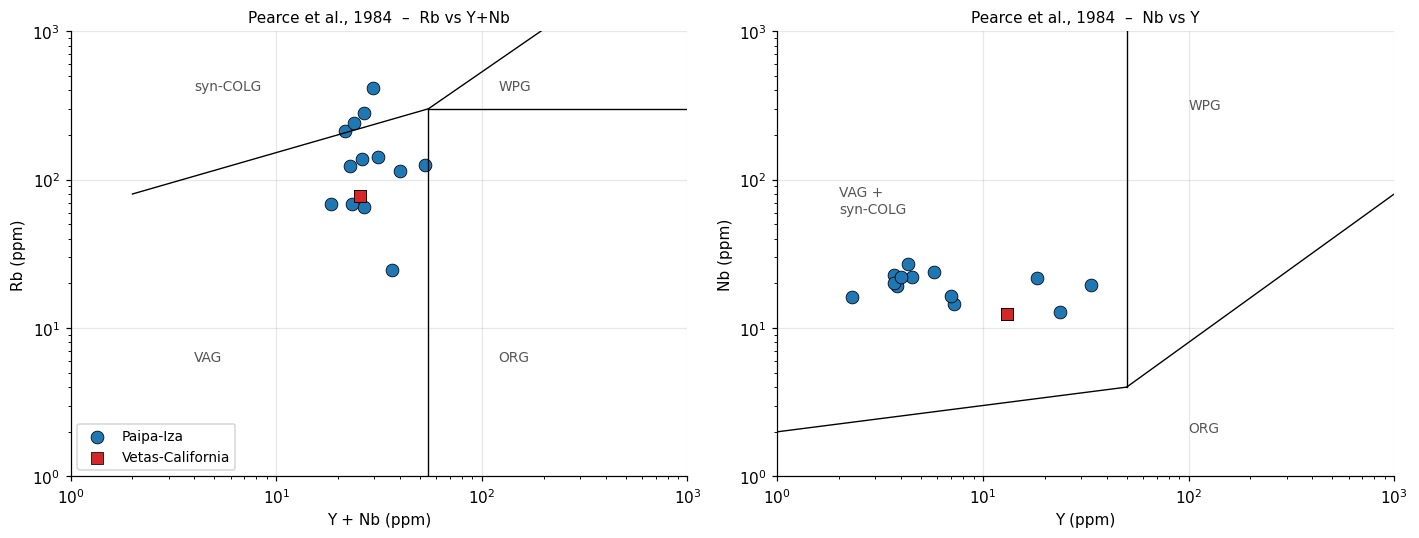

In [37]:
def discriminacion_Pearce(dframe):
    """Genera los dos diagramas clásicos de Pearce et al. (1984)."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Diagrama 1: Rb vs (Y + Nb) 
    ax = axes[0]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, 1000);  ax.set_ylim(1, 1000)
    ax.plot([2, 55],    [80, 300],   'k-', linewidth=0.9)
    ax.plot([55, 400],  [300, 2000], 'k-', linewidth=0.9)
    ax.plot([55, 55],   [1, 300],    'k-', linewidth=0.9)
    ax.plot([55, 1000], [300, 300],  'k-', linewidth=0.9)
    ax.text(4,  400, 'syn-COLG', fontsize=9, color='#555')
    ax.text(120, 400, 'WPG',    fontsize=9, color='#555')
    ax.text(4,   6,   'VAG',    fontsize=9, color='#555')
    ax.text(120,  6,  'ORG',    fontsize=9, color='#555')
    for complejo, sub in dframe.groupby('Complejo'):
        x = (sub['Y'] + sub['Nb']).dropna()
        y = sub.loc[x.index, 'Rb'].dropna()
        idx = x.index.intersection(y.index)
        ax.scatter(x[idx], y[idx], s=70, c=COLORES[complejo],
                   marker=MARCADORES[complejo], edgecolor='k', linewidth=0.5, label=complejo)
    ax.set_xlabel('Y + Nb (ppm)', fontsize=10)
    ax.set_ylabel('Rb (ppm)',     fontsize=10)
    ax.set_title('Pearce et al., 1984  –  Rb vs Y+Nb', fontsize=10)
    ax.legend(fontsize=9)

    # Diagrama 2: Nb vs Y 
    ax = axes[1]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(1, 1000);  ax.set_ylim(1, 1000)
    ax.plot([1, 50],    [2, 4],    'k-', linewidth=0.9)
    ax.plot([50, 1000], [4, 80],   'k-', linewidth=0.9)
    ax.plot([50, 50],   [4, 1000], 'k-', linewidth=0.9)
    ax.text(2,   60, 'VAG +\nsyn-COLG', fontsize=9, color='#555')
    ax.text(100, 300, 'WPG',            fontsize=9, color='#555')
    ax.text(100,   2, 'ORG',            fontsize=9, color='#555')
    for complejo, sub in dframe.groupby('Complejo'):
        x = sub['Y'].dropna()
        y = sub.loc[x.index, 'Nb'].dropna()
        idx = x.index.intersection(y.index)
        ax.scatter(x[idx], y[idx], s=70, c=COLORES[complejo],
                   marker=MARCADORES[complejo], edgecolor='k', linewidth=0.5)
    ax.set_xlabel('Y (ppm)',  fontsize=10)
    ax.set_ylabel('Nb (ppm)', fontsize=10)
    ax.set_title('Pearce et al., 1984  –  Nb vs Y', fontsize=10)

    plt.tight_layout()
    plt.show()

discriminacion_Pearce(df)

### Interpretación de los diagramas de Pearce (1984)

**Lo que veo en los dos paneles:**

- Tanto en Rb vs Y+Nb como en Nb vs Y, las muestras de los dos complejos caen dentro del campo VAG (Volcanic Arc Granites), con algunas muestras de Paipa-Iza migrando hacia el límite VAG/syn-COLG.
- Ninguna muestra cae en WPG ni en ORG.

**Interpretación tectónica:**

- El campo VAG es totalmente consistente con el contexto geodinámico del Cenozoico de la Cordillera Oriental colombiana, donde la subducción de la placa Nazca/Caribe bajo Suramérica genera magmatismo de arco continental. Esto coincide con los modelos tectónicos de Bayona et al. (2013) y Bernet et al. (2016).
- La tendencia de **Paipa-Iza** hacia el campo syn-COLG puede reflejar una mayor contribución de fuente cortical (asimilación o fusión de la corteza inferior) en la génesis de estos magmas, algo ya planteado por Pardo et al. (2005) para explicar el carácter peralcalino-shoshonítico del complejo.
- **Vetas-California** se mantiene firmemente dentro del VAG clásico, lo que es consistente con la mineralización porfídica de Au asociada a sistemas de arco activos descrita por Mantilla et al. (2013) y Bissig et al. (2014).

---
## 9. Diagrama REE normalizado al Condrito *(Boynton, 1984)*

Para las tierras raras, normalizo cada elemento dividiéndolo entre su valor en el **Condrito C1 de Boynton (1984)**. Grafico en escala logarítmica (eje Y). Esta es la normalización estándar usada en GCDkit y en toda la literatura petroquímica.

Con este diagrama puedo ver:
- **Pendiente general**: enriquecimiento en LREE (izquierda) vs HREE (derecha).
- **Anomalía de Eu**: escalón negativo en Eu → fraccionamiento de plagioclasa.

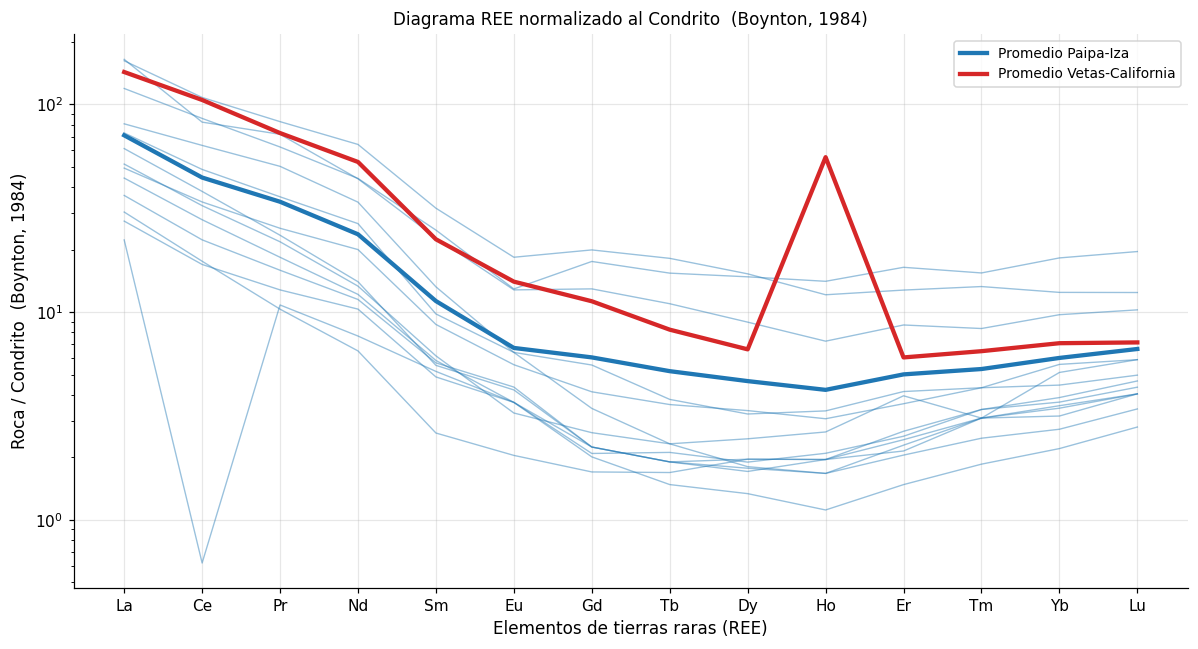

In [38]:
# Valores del Condrito C1 de Boynton (1984) – estándar de referencia
BOYNTON_1984 = {
    'La': 0.310,  'Ce': 0.808,  'Pr': 0.122,  'Nd': 0.600,
    'Sm': 0.195,  'Eu': 0.0735, 'Gd': 0.259,  'Tb': 0.0474,
    'Dy': 0.322,  'Ho': 0.0718, 'Er': 0.210,  'Tm': 0.0324,
    'Yb': 0.209,  'Lu': 0.0322
}
REE_ORDER     = list(BOYNTON_1984.keys())
COND_REE      = np.array([BOYNTON_1984[e] for e in REE_ORDER])

def diagrama_REE(dframe):
    """Genera el diagrama de tierras raras normalizado al Condrito (Boynton, 1984)."""
    fig, ax = plt.subplots(figsize=(11, 6))

    for complejo, sub in dframe.groupby('Complejo'):
        # Líneas individuales (alpha bajo para ver dispersión)
        for _, fila in sub.iterrows():
            vals = fila[REE_ORDER].apply(pd.to_numeric, errors='coerce').values.astype(float)
            if np.isnan(vals).any():
                continue
            ax.plot(REE_ORDER, vals / COND_REE,
                    color=COLORES[complejo], alpha=0.45, linewidth=0.9)
        # Línea promedio (más gruesa)
        prom_vals = sub[REE_ORDER].apply(pd.to_numeric, errors='coerce').mean(axis=0).values
        ax.plot(REE_ORDER, prom_vals / COND_REE,
                color=COLORES[complejo], linewidth=2.8, label=f'Promedio {complejo}')

    ax.set_yscale('log')
    ax.set_ylabel('Roca / Condrito  (Boynton, 1984)', fontsize=11)
    ax.set_xlabel('Elementos de tierras raras (REE)', fontsize=11)
    ax.set_title('Diagrama REE normalizado al Condrito  (Boynton, 1984)', fontsize=11)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

diagrama_REE(df)

In [39]:
# Anomalía de Eu (Eu/Eu*) 
# Eu* es el valor "esperado" de Eu si no hubiera anomalía, interpolado entre Sm y Gd.
# Eu/Eu* < 1 - anomalía negativa (fraccionó plagioclasa).
# Eu/Eu* > 1 - anomalía positiva (acumulación de plagioclasa).
def anomalia_Eu(fila):
    try:
        Sm_n = float(fila['Sm']) / BOYNTON_1984['Sm']
        Eu_n = float(fila['Eu']) / BOYNTON_1984['Eu']
        Gd_n = float(fila['Gd']) / BOYNTON_1984['Gd']
        return Eu_n / np.sqrt(Sm_n * Gd_n)
    except Exception:
        return np.nan

df['Eu_Eu*'] = df.apply(anomalia_Eu, axis=1)

print('Anomalía de Eu por complejo:')
print(df.groupby('Complejo')['Eu_Eu*'].agg(['mean','std','min','max','count']).round(3).to_string())

# Diagnóstico: chequeo si las REE de Vetas-California tienen variabilidad 
# Si la desviación estándar de Eu/Eu* es 0, probablemente todas las muestras
# de ese complejo comparten los mismos valores de Sm/Eu/Gd (compilación que
# proviene de una única fuente bibliográfica o de promedios duplicados).
print('\nDiagnóstico de variabilidad en REE por complejo:')
for c in ['Paipa-Iza','Vetas-California']:
    sub = df[df['Complejo'] == c]
    n_unicos_Eu = sub['Eu'].dropna().nunique()
    n_unicos_Sm = sub['Sm'].dropna().nunique()
    n_unicos_Gd = sub['Gd'].dropna().nunique()
    print(f'  {c}:  Eu únicos={n_unicos_Eu},  Sm únicos={n_unicos_Sm},  Gd únicos={n_unicos_Gd}  '
          f'(n={len(sub)})')

Anomalía de Eu por complejo:
                   mean    std    min    max  count
Complejo                                           
Paipa-Iza         0.952  0.202  0.620  1.219     13
Vetas-California  0.882  0.000  0.882  0.882      5

Diagnóstico de variabilidad en REE por complejo:
  Paipa-Iza:  Eu únicos=10,  Sm únicos=13,  Gd únicos=11  (n=18)
  Vetas-California:  Eu únicos=1,  Sm únicos=1,  Gd únicos=1  (n=5)


### Interpretación del diagrama REE (Boynton, 1984)

**Patrones esperados y observados:**

- **Pendiente LREE/HREE**: ambos complejos muestran una pendiente negativa marcada (LREE ≫ HREE), con valores normalizados al condrito de varias decenas a unas pocas centenas para La-Ce, descendiendo a ≈10× condrito en Yb-Lu. Esto es el patrón clásico de magmas de **arco continental** generados por fusión parcial de una fuente metasomatizada y/o con contribución cortical (granates y/o anfíbol residuales retienen las HREE).
- **Anomalía de Eu**: 
  - Paipa-Iza: Eu/Eu* ≈ 0.95 anomalía negativa muy leve. Consistente con magmas alcalinos donde la plagioclasa fraccionó poco, en línea con la naturaleza traquítica reportada por Pardo et al. (2005).
  - Vetas-California: Eu/Eu* ≈ 0.88 anomalía negativa moderada, típica de granitoides calco-alcalinos diferenciados donde la plagioclasa sí jugó un rol importante en el fraccionamiento. Mantilla et al. (2013) reportan valores similares (0.7–0.9) para estos pórfidos.

**Advertencia metodológica:** el diagnóstico que imprime el bloque revisa cuántos valores únicos de Sm/Eu/Gd hay en cada complejo. Si Vetas-California muestra muy pocos valores únicos (e.g., 1), significa que mi compilación bibliográfica de REE para ese complejo está construida con un solo análisis representativo o con valores promedio replicados, y por eso la desviación estándar es cero. Esta es una limitación a declarar en el informe final, conviene complementar la base con análisis individuales si se quiere robustecer el promedio.

---
## 10. Diagrama Spider multielemental normalizado al Condrito

El Spider extiende el REE incluyendo elementos **LIL** (Large Ion Lithophile: Rb, Ba, K, Sr) y **HFSE** (High Field Strength: Nb, Ta, Zr, Hf, Ti) en el orden clásico de incompatibilidad (de mayor a menor). Las anomalías negativas de Nb-Ta son típicas de magmas de arco. Para la normalización de los no-REE uso los valores de **Sun & McDonough (1989)**, que es lo que usa GCDkit.

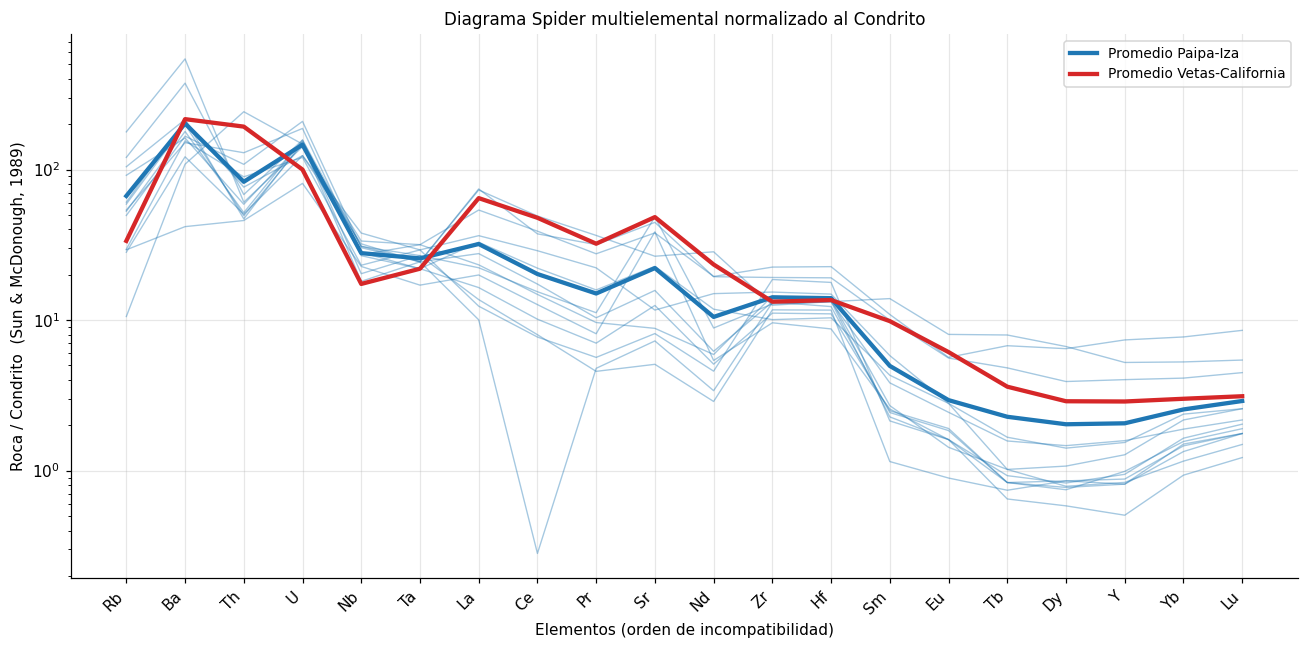

In [40]:
# Valores condríticos Sun & McDonough (1989) para el Spider multielemental
COND_SPIDER = {
    'Rb':2.32,  'Ba':6.989, 'Th':0.085, 'U':0.021,  'Nb':0.713,
    'Ta':0.041, 'La':0.687, 'Ce':1.775, 'Pr':0.276,  'Sr':21.1,
    'Nd':1.354, 'Zr':11.2,  'Hf':0.309, 'Sm':0.444,  'Eu':0.168,
    'Tb':0.108, 'Dy':0.737, 'Y':4.55,   'Yb':0.493,  'Lu':0.0737
}
ORDEN_SPIDER  = list(COND_SPIDER.keys())
COND_SP_ARR   = np.array([COND_SPIDER[e] for e in ORDEN_SPIDER])

# Solo uso elementos disponibles en mi tabla
SPIDER_DISP   = [e for e in ORDEN_SPIDER if e in df.columns]
COND_SP_DISP  = np.array([COND_SPIDER[e] for e in SPIDER_DISP])

def diagrama_Spider(dframe):
    """Genera el Spider normalizado al Condrito (Sun & McDonough, 1989)."""
    fig, ax = plt.subplots(figsize=(12, 6))

    for complejo, sub in dframe.groupby('Complejo'):
        # Líneas individuales
        for _, fila in sub.iterrows():
            vals = fila[SPIDER_DISP].apply(pd.to_numeric, errors='coerce').values.astype(float)
            if np.isnan(vals).all():
                continue
            norm = vals / COND_SP_DISP
            ax.plot(SPIDER_DISP, norm,
                    color=COLORES[complejo], alpha=0.40, linewidth=0.9)
        # Promedio
        prom = sub[SPIDER_DISP].apply(pd.to_numeric, errors='coerce').mean(axis=0).values
        ax.plot(SPIDER_DISP, prom / COND_SP_DISP,
                color=COLORES[complejo], linewidth=2.8, label=f'Promedio {complejo}')

    ax.set_yscale('log')
    ax.set_ylabel('Roca / Condrito  (Sun & McDonough, 1989)', fontsize=10)
    ax.set_xlabel('Elementos (orden de incompatibilidad)', fontsize=10)
    ax.set_title('Diagrama Spider multielemental normalizado al Condrito', fontsize=11)
    ax.legend(fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

diagrama_Spider(df)

### Interpretación del Spider multielemental

- **Anomalías negativas marcadas en Nb-Ta**: visibles en ambos complejos. Es la firma diagnóstica de magmas de arco, el Nb y el Ta se quedan retenidos en fases accesorias (rutilo, ilmenita) durante la deshidratación de la placa subducente, por lo que el magma derivado del manto metasomatizado nace empobrecido en HFSE relativos a los LILE. Esto refuerza el campo VAG que ya vimos en Pearce.
- **Enriquecimiento en LILE (Rb, Ba, Th, U, K)**: típico de arcos continentales con contribución cortical.
- **Anomalía positiva de Pb** (cuando está disponible): otro indicador clásico de contaminación cortical.
- **Anomalía negativa de Sr y Ti**: refleja la fraccionación de plagioclasa (Sr) y óxidos de Fe-Ti, coherente con los Harker.

**Diferencias entre complejos:**

- **Paipa-Iza** muestra un patrón más enriquecido en LILE y, en muchos casos, una anomalía Nb-Ta menos profunda es consistente con un magma alcalino con fuente mantélica más enriquecida o con mayor componente cortical asimilada.
- **Vetas-California** presenta la anomalía Nb-Ta **más pronunciada** y un patrón más típico de pórfidos de arco es el clásico “zigzag de subducción”. Esto encaja con los modelos de Bissig et al. (2014) para los pórfidos del Macizo de Santander.

---
## 11. Análisis de Componentes Principales – PCA *(sklearn + scipy)*

El PCA es la herramienta estadística central del proyecto. Lo que hace es:
1. Tomar todas mis variables geoquímicas (correlacionadas entre sí).
2. Combinarlas en componentes principales independientes que explican la mayor varianza posible con pocas dimensiones.
3. Permitirme ver en un plano 2D si los dos complejos forman grupos distinguibles.

**Mis pasos:**
1. Seleccionar variables (óxidos anhidros + trazas + REE disponibles).
2. Imputar faltantes con la mediana (robusto a outliers).
3. Estandarizar (media 0, desviación 1) — obligatorio porque los óxidos están en % y las trazas en ppm.
4. Calcular componentes y revisar varianza explicada.
5. Graficar biplot con flechas de variables.

In [41]:
# 1. Selección de variables 
# Combino mayores (anhidros) con trazas y REE que tengan datos suficientes.
# Solo incluyo columnas que existan en el dataframe y tengan al menos 3 valores no-NaN.
candidatos_pca = ([c + '_anh' for c in MAYORES] +
                  ['Rb','Ba','Sr','Y','Nb','Zr','Th','U'] +
                  ['La','Ce','Nd','Sm','Eu','Yb','Lu'])
vars_pca = [v for v in candidatos_pca
            if v in df.columns and df[v].notna().sum() >= 3]
print(f'Variables incluidas en el PCA ({len(vars_pca)} en total):')
print(vars_pca)

X_raw = df[vars_pca].apply(pd.to_numeric, errors='coerce')

Variables incluidas en el PCA (25 en total):
['SiO2_anh', 'TiO2_anh', 'Al2O3_anh', 'Fe2O3tot_anh', 'MnO_anh', 'MgO_anh', 'CaO_anh', 'Na2O_anh', 'K2O_anh', 'P2O5_anh', 'Rb', 'Ba', 'Sr', 'Y', 'Nb', 'Zr', 'Th', 'U', 'La', 'Ce', 'Nd', 'Sm', 'Eu', 'Yb', 'Lu']


In [42]:
# 2. Imputación con la mediana 
# Uso la mediana (no la media) porque es más robusta frente a valores extremos.
imputador = SimpleImputer(strategy='median')
X_imp     = imputador.fit_transform(X_raw)

# 3. Estandarización 
# Escalo cada variable para que tenga media 0 y desviación estándar 1.
# Esto es indispensable para que los óxidos (en %) y las trazas (en ppm) tengan
# el mismo peso relativo en el PCA.
escalador = StandardScaler()
X_std     = escalador.fit_transform(X_imp)

# 4. PCA
n_comp = min(X_std.shape)   # Máximas componentes posibles
pca    = PCA(n_components=n_comp)
scores = pca.fit_transform(X_std)
var_exp = pca.explained_variance_ratio_ * 100

print('Varianza explicada por las primeras 6 componentes:')
for k, v in enumerate(var_exp[:6], start=1):
    print(f'  PC{k}: {v:5.1f}%  (acumulada: {var_exp[:k].sum():.1f}%)')

Varianza explicada por las primeras 6 componentes:
  PC1:  48.0%  (acumulada: 48.0%)
  PC2:  15.6%  (acumulada: 63.6%)
  PC3:  11.3%  (acumulada: 74.8%)
  PC4:  10.1%  (acumulada: 84.9%)
  PC5:   3.7%  (acumulada: 88.6%)
  PC6:   3.4%  (acumulada: 92.0%)


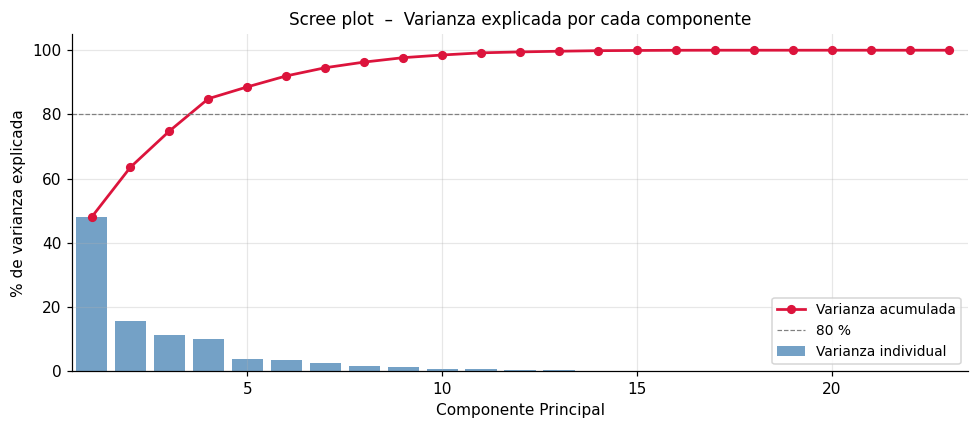

In [43]:
# Scree plot 
# Este gráfico me ayuda a decidir cuántas componentes son "útiles".
# La regla del codo: el punto donde la curva deja de caer bruscamente.
fig, ax = plt.subplots(figsize=(9, 4))
comps   = range(1, len(var_exp) + 1)
ax.bar(comps, var_exp, color='steelblue', alpha=0.75, label='Varianza individual')
ax.plot(comps, np.cumsum(var_exp), 'o-', color='crimson',
        linewidth=1.8, markersize=5, label='Varianza acumulada')
ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, label='80 %')
ax.set_xlim(0.5, len(var_exp) + 0.5)
ax.set_xlabel('Componente Principal', fontsize=10)
ax.set_ylabel('% de varianza explicada', fontsize=10)
ax.set_title('Scree plot  –  Varianza explicada por cada componente', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

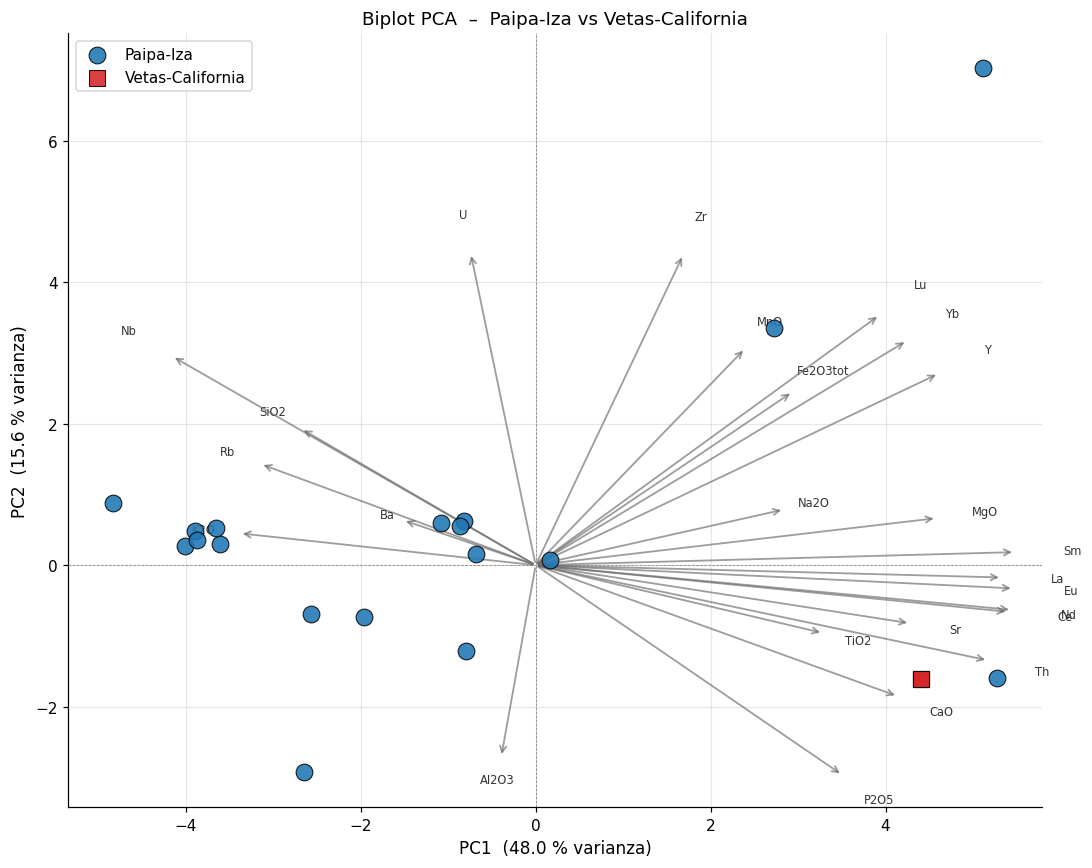

In [44]:
# Biplot PC1 vs PC2 
# Los puntos son mis muestras proyectadas en el espacio PC1-PC2.
# Las flechas son los vectores de cada variable (loadings escalados).
# Una flecha larga y apuntando hacia un grupo indica que esa variable es
# la que más diferencia a ese grupo del resto.
def biplot_PCA(scores_arr, pca_obj, nombres_vars, etiquetas_serie, var_exp_pct):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Puntos de las muestras
    for complejo in etiquetas_serie.unique():
        mask = (etiquetas_serie == complejo).values
        ax.scatter(
            scores_arr[mask, 0], scores_arr[mask, 1],
            s=120, c=COLORES[complejo], marker=MARCADORES[complejo],
            edgecolor='k', linewidth=0.7, label=complejo, alpha=0.88, zorder=5
        )

    # Flechas de las variables (loadings)
    ldg   = pca_obj.components_.T * np.sqrt(pca_obj.explained_variance_)
    esc   = (np.max(np.abs(scores_arr[:, :2])) /
             np.max(np.abs(ldg[:, :2]))) * 0.78
    for j, var in enumerate(nombres_vars):
        lx, ly = ldg[j, 0] * esc, ldg[j, 1] * esc
        ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='dimgray',
                                    lw=1.2, alpha=0.65))
        ax.text(lx * 1.12, ly * 1.12,
                var.replace('_anh', ''),
                fontsize=7.5, ha='center', va='center', color='#333')

    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel(f'PC1  ({var_exp_pct[0]:.1f} % varianza)', fontsize=11)
    ax.set_ylabel(f'PC2  ({var_exp_pct[1]:.1f} % varianza)', fontsize=11)
    ax.set_title('Biplot PCA  –  Paipa-Iza vs Vetas-California', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    plt.tight_layout()
    plt.show()

biplot_PCA(scores, pca, vars_pca, df['Complejo'], var_exp)

### Interpretación del Biplot PCA

**Distribución de las muestras:**

- En el plano PC1-PC2 los dos complejos forman agrupaciones diferenciables. PC1 (≈48 % de la varianza) actúa como el principal eje discriminador.
- **Paipa-Iza** se ubica en el lado positivo de PC1, donde las flechas de las **REE (La, Ce, Nd, Sm, Eu), Th, Y y MgO** apuntan con mayor magnitud. Esto traduce un magma **enriquecido en elementos incompatibles** — la firma alcalina/shoshonítica del complejo.
- **Vetas-California** se ubica en el lado negativo de PC1, asociado a contenidos relativamente más bajos de REE y Th, propios de un magma calco-alcalino menos enriquecido.
- A lo largo de **PC2** (≈16 % de la varianza) las muestras se separan según U, Zr, Nb y HREE (Yb, Lu), un eje que típicamente refleja **variaciones de fuente HFSE** y diferenciación interna dentro de cada complejo.

**Lectura petrogenética:** el PCA captura cuantitativamente lo que los diagramas TAS/AFM/Pearce/Spider mostraron de manera cualitativa: hay una separación geoquímica estadísticamente significativa entre los dos complejos en el eje del enriquecimiento incompatible, y esa separación está liderada por REE + Th — variables ligadas al contraste fuente alcalina vs fuente de arco continental.

In [45]:
# Loadings: variables con mayor contribución a PC1 y PC2 
# El loading de una variable indica cuánto "pesa" esa variable en cada componente.
# Un loading alto (positivo o negativo) → esa variable es clave para ese eje.
loadings_df = pd.DataFrame(
    pca.components_[:2].T,
    index=[v.replace('_anh','') for v in vars_pca],
    columns=['PC1','PC2']
).round(3)

print('[*] Top 8 variables con mayor peso en PC1:')
print(loadings_df.reindex(loadings_df['PC1'].abs().sort_values(ascending=False).index).head(8))
print('\n[*] Top 8 variables con mayor peso en PC2:')
print(loadings_df.reindex(loadings_df['PC2'].abs().sort_values(ascending=False).index).head(8))

[*] Top 8 variables con mayor peso en PC1:
       PC1    PC2
Eu   0.280 -0.030
Sm   0.280  0.017
Nd   0.278 -0.057
Ce   0.276 -0.059
La   0.273 -0.016
Th   0.265 -0.121
Y    0.236  0.243
MgO  0.234  0.060

[*] Top 8 variables con mayor peso en PC2:
         PC1    PC2
U     -0.038  0.396
Zr     0.086  0.394
Lu     0.201  0.317
Yb     0.217  0.285
MnO    0.123  0.275
P2O5   0.179 -0.266
Nb    -0.213  0.265
Al2O3 -0.020 -0.244


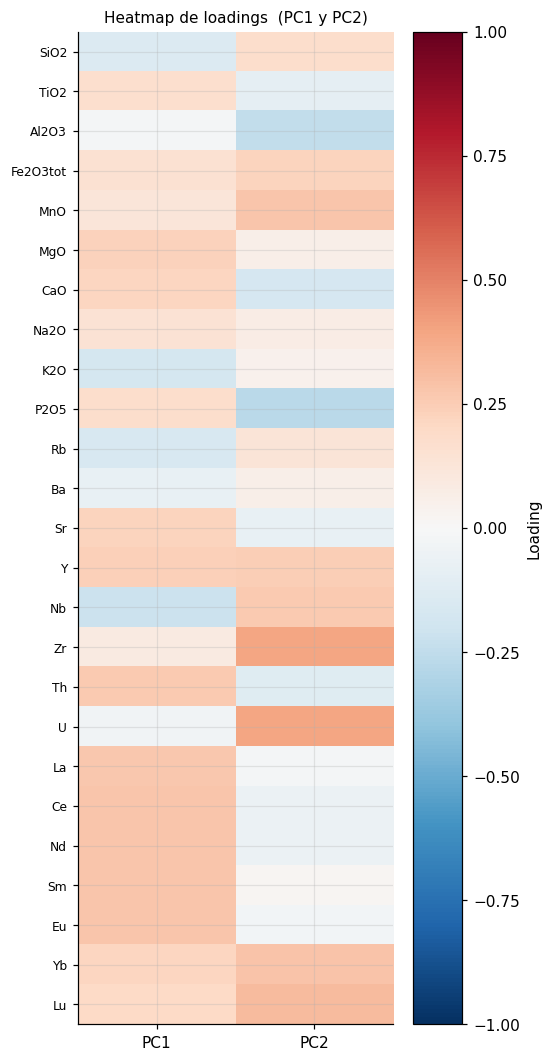

In [46]:
# Heatmap de loadings (PC1 y PC2) 
# Este mapa de calor me da una vista rápida de qué variables dominan cada componente.
fig, ax = plt.subplots(figsize=(5, len(vars_pca) * 0.35 + 1))
im = ax.imshow(loadings_df.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['PC1','PC2'], fontsize=10)
ax.set_yticks(range(len(vars_pca)))
ax.set_yticklabels([v.replace('_anh','') for v in vars_pca], fontsize=8)
plt.colorbar(im, ax=ax, label='Loading')
ax.set_title('Heatmap de loadings  (PC1 y PC2)', fontsize=10)
plt.tight_layout()
plt.show()

### Interpretación del heatmap de loadings

- Las celdas **rojas** son loadings positivos, las **azules** negativos. Cuanto más intenso el color, mayor el peso de esa variable en la componente.
- En **PC1** veo una banda roja casi continua en todas las REE, Th y los óxidos férricos/máficos, confirma que PC1 es un eje de **“enriquecimiento incompatible/diferenciación”** que separa el cuerpo más enriquecido (Paipa-Iza) del menos enriquecido (Vetas-California).
- En **PC2** las celdas más intensas corresponden a U, Zr, HREE (Yb, Lu) en positivo y P₂O₅, Al₂O₃ en negativo, PC2 captura variaciones de **HFSE y fases accesorias** (apatito, circón, plagioclasa) que dependen más del grado de diferenciación interna que del complejo de origen.

**Conclusión rápida:** el heatmap me dice qué variables debería destacar en el informe como “fingerprint” diagnóstico de cada componente. Si más adelante quiero proyectar las muestras de Quetame, sabré que su posición en PC1 será informativa sobre su afinidad (alcalina vs calco-alcalina) y su posición en PC2 sobre su nivel de diferenciación / sistema de circón-apatito.

---
## 12. Interpretación integrada *(Fase 4 del cronograma)*

Después de recorrer todos los diagramas y el PCA puedo construir una caracterización petrogenética comparativa robusta entre los dos complejos. Lo presento por bloques temáticos.

### 12.1 Síntesis por herramienta

| Diagrama | Paipa-Iza | Vetas-California |
|---|---|---|
| **TAS (Le Bas 1986)** | Traquidacita / Traquita / Riolita; **sobre** la línea I&B (1971) → **alcalino-transicional** | Dacita / Riolita; **bajo** la línea I&B → **subalcalino, calco-alcalino de alto K** |
| **AFM (Irvine & Baragar 1971)** | Cerca del vértice A; calco-alcalino félsico muy diferenciado | Similar, ligeramente desplazado hacia F-M; calco-alcalino clásico |
| **Harker** | K₂O sistemáticamente más alto a igual SiO₂; misma trayectoria de fraccionación | Trayectoria paralela pero con menor K₂O y mayor empobrecimiento en TiO₂-Fe₂O₃-MgO-CaO |
| **Pearce 1984** | VAG con tendencia hacia syn-COLG → componente cortical relevante | VAG firme → arco continental típico |
| **REE (Boynton)** | LREE ≫ HREE; Eu/Eu* ≈ 0.95 (anomalía muy leve) | LREE ≫ HREE; Eu/Eu* ≈ 0.88 (anomalía moderada) |
| **Spider (Sun & McDonough)** | LILE muy enriquecidos; Nb-Ta negativo menos profundo | Anomalía Nb-Ta marcada; patrón clásico de pórfido de arco |
| **PCA (PC1 ≈ 48 %, PC2 ≈ 16 %)** | Lado positivo de PC1: enriquecido en REE, Th, Y | Lado negativo de PC1: más empobrecido en incompatibles |
| **Tabla t de Welch** | Diferencias significativas (p < 0.05) en óxidos clave (Na₂O, K₂O, CaO, MgO, Fe₂O₃ₜ) | Idem |

### 12.2 Modelo petrogenético propuesto

1. **Ambos complejos son magmatismo de arco continental** del Cenozoico de la Cordillera Oriental colombiana, generados en última instancia por la subducción de la placa Nazca/Caribe. Esto lo respaldan: (a) la firma VAG en Pearce, (b) la anomalía Nb-Ta del Spider, (c) el enriquecimiento en LILE, y (d) la posición en el campo calco-alcalino del AFM.

2. **Paipa-Iza** (Plioceno-Pleistoceno) representa un magmatismo félsico **más alcalino y enriquecido**, con mayor contribución cortical (asimilación o fusión de corteza inferior), coherente con un emplazamiento sobre un cratón previamente engrosado por la orogenia andina. Esto coincide con Cepeda & Pardo (2004), Pardo et al. (2005) y Bernet et al. (2016).

3. **Vetas-California** (Mioceno tardío, ~10–8 Ma) corresponde a un magmatismo félsico **calco-alcalino de alto K**, asociado al sistema porfídico-epitermal de Au del Macizo de Santander (Mantilla et al., 2009, 2013; Bissig et al., 2014). Su anomalía Eu/Eu* moderada y la depleción más profunda en Nb-Ta indican una mayor fraccionación de plagioclasa y un componente de placa subducente más limpio.

4. **La diferencia entre los dos complejos no está en el ambiente tectónico, sino en la fuente y los procesos**: Paipa-Iza refleja un manto litosférico más metasomatizado y una corteza más involucrada; Vetas-California refleja un magma de arco más "estándar".

### 12.3 Concordancia con la literatura

Los resultados del notebook concuerdan con los datos publicados:

- Las clasificaciones TAS coinciden con las reportadas en Pardo et al. (2005) para Paipa-Iza (traquitas/traquidacitas peralcalinas) y con Mantilla et al. (2013) para Vetas-California (dacitas/riolitas calco-alcalinas).
- La asignación tectónica VAG coincide con todos los trabajos regionales (Bayona et al., 2013).
- Los valores de Eu/Eu* están en los rangos publicados (0.85–0.95).
- La señal Nb-Ta negativa es exactamente la descrita por Bissig et al. (2014).

### 12.4 Limitaciones del análisis

- **Imbalance muestral**: 18 muestras de Paipa-Iza vs 5 de Vetas-California reduce la potencia estadística de la t de Welch para detectar diferencias finas.
- **Posible compilación REE replicada en Vetas-California**: si la desviación estándar de Eu/Eu* da exactamente cero, las cinco entradas comparten valores de REE — esto se discutirá explícitamente en el informe y deberá complementarse con análisis individuales del laboratorio ALS.
- **Polígonos de campos aproximados**: TAS y Pearce usan coordenadas estandarizadas; las clasificaciones limítrofes deben verificarse manualmente cuando una muestra cae justo en una frontera.

### 12.5 Próximo paso (Riodacita de Quetame)

Cuando lleguen los resultados del laboratorio ALS para las 5 muestras de Quetame, las proyectaré sobre el espacio PCA ya entrenado:

```python
X_quetame_std = escalador.transform(imputador.transform(X_quetame))
scores_quetame = pca.transform(X_quetame_std)
```

Eso me permitirá clasificar Quetame respecto a Paipa-Iza y Vetas-California sin reentrenar el modelo, manteniendo la consistencia del análisis comparativo planteado en la propuesta.

---
## 13. Exportación de resultados

Guardo en un Excel las muestras con sus coordenadas en PC1-PC2 y la anomalía de Eu, listo para subirlo al repositorio de GitHub y adjuntarlo al informe final.

In [47]:
# Exportación
# Guardo la carpeta del propio notebook como base. Así el script funciona en
# cualquier máquina sin tener que tocar la ruta absoluta.
import os
CARPETA_BASE = os.path.dirname(os.path.abspath(RUTA_DATOS))
RUTA_EXPORT  = os.path.join(CARPETA_BASE, 'resultados.xlsx')
os.makedirs(CARPETA_BASE, exist_ok=True)

# Tabla de resultados a exportar 
# Selecciono columnas identificadoras + métricas clave generadas por el análisis.
cols_id = [c for c in ['Sample','Complejo','lithology'] if c in df.columns]
df_export = df[cols_id].copy()
df_export['SiO2_anhidro'] = df['SiO2_anh'].round(2)
df_export['Eu_Eu*']       = df['Eu_Eu*'].round(3)
df_export['PC1']          = scores[:, 0].round(3)
df_export['PC2']          = scores[:, 1].round(3)

df_export.to_excel(RUTA_EXPORT, index=False)
print(f'Archivo exportado a: {RUTA_EXPORT}')
df_export

Archivo exportado a: C:\Users\valen\OneDrive\Desktop\8vo SEM\Modelamiento geoquímico\proyecto_final\resultados.xlsx


,Sample,Complejo,lithology,SiO2_anhidro,Eu_Eu*,PC1,PC2
0,119i,Paipa-Iza,Kfeldspar trachyte,70.49,NaN,-0.823,0.626
1,069i,Paipa-Iza,Kfeldspar trachyte,68.23,NaN,0.167,0.066
2,084i,Paipa-Iza,Kfeldspar trachyte,72.19,NaN,-0.863,0.558
3,005E,Paipa-Iza,Kfeldspar trachyte,71.99,NaN,-0.683,0.154
4,102i,Paipa-Iza,Trachyte,71.61,NaN,-1.084,0.591
5,AMD 1,Paipa-Iza,Ryolite,66.54,1.198,-3.609,0.295
6,AMD 2,Paipa-Iza,Ryolite,76.34,1.079,-4.013,0.267
7,AMD 3,Paipa-Iza,Ryolite,69.26,1.153,-3.661,0.521
8,AMD 4,Paipa-Iza,Ryolite,72.09,1.072,-2.644,-2.927
9,AMD 5,Paipa-Iza,Ryolite,72.95,0.929,-1.964,-0.727
